# 01 — Baseline balance (S1)

**Notebook id**: `01_baseline_balance` → vault `03.2-balance-baseline.md`

Is there a major imbalance on baseline (S1) covariates between groups? We report **standardised mean differences** (Austin) and visualise them as a **Love plot** (including a **PF score S1** row), and we confirm the baseline lesion load is equivalent — crucially on the **patellofemoral block at S1 specifically** (`tf.baseline_pf_balance`), with a **TOST** equivalence test rather than reading a non-significant difference as equivalence (absence of evidence ≠ evidence of absence; revue 2026-05-29). So the PF progression contrast is not driven by a starting-point difference or a ceiling effect.

In [ ]:
import sys
from pathlib import Path

current = Path().absolute().parent
sys.path.insert(0, (current / "src").as_posix())


In [14]:
# --- Setup (idempotent, fresh-kernel reproducible) ---
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

from constants import (
    RANDOM_SEED,
    SITES,
    SITES_PF,
    SITES_FT,
    SITES_BINARY,
    SITES_ORDINAL,
    GROUPS,
    BLOCKS,
    N_TOTAL,
    N_TOTAL_ANALYSABLE,
    N_MENISCUS,
    N_CYCLOPS,
    SCORE_MAX,
    SCORE_MAX_COLLAPSED,
)
import loaders
import preprocessing as pp
import tests_freq as tf
import reporting as rpt
import bayes_models as bm
import viz

np.random.seed(RANDOM_SEED)
viz.set_pub_style()


In [15]:
# --- Load & preprocess (canonical pipeline) ---
df = loaders.load_combined()
df = pp.apply_date_hygiene(df)  # composite-key (group, anonyme) date hygiene
df = pp.add_derived(df)  # lesion_pf/ft, female, deltas, worsened_pf, ...
wide = pp.to_wide(df)  # one row per patient (group, anonyme)
patient = pp.to_patient(df)  # static covariates per patient

# Patient-level covariates joined onto the wide outcomes (for H3 / sensitivity).
_cov = [
    c
    for c in [
        "group",
        "anonyme",
        "female",
        "sexe",
        "pivot_pivot_contact",
        "travail_physique",
        "tabac",
        "age_at_trauma",
        "imc",
        "taille",
        "poids",
    ]
    if c in patient.columns
]
merged = wide.merge(patient[_cov], on=["group", "anonyme"], how="left")

print(
    "long:",
    df.shape,
    "| wide:",
    wide.shape,
    "| patient:",
    patient.shape,
    "| merged:",
    merged.shape,
)
# Composite-key sentinel: 19 Anonyme ids are reused across the two sheets.
assert (df.groupby(["group", "anonyme"]).size() == 2).all(), "composite key broken"


long: (138, 33) | wide: (69, 53) | patient: (69, 11) | merged: (69, 62)


## 1. Table 1 (SMD) recap

In [16]:
table1 = rpt.make_table1(patient)
print(table1.to_string(index=False))


           variable        level          cyclops         meniscus pvalue   smd
                  n                            49               20             
      age_at_trauma median [IQR] 30.9 [22.5–37.0] 24.9 [19.8–31.2]  0.084 +0.48
                imc median [IQR] 24.4 [22.0–26.4] 24.8 [23.0–26.8]  0.615 -0.08
             taille median [IQR]    1.7 [1.6–1.8]    1.7 [1.7–1.8]  0.272 -0.25
              poids median [IQR] 70.0 [63.0–81.0] 76.5 [65.0–83.0]  0.340 -0.19
               sexe            1       18 (36.7%)       11 (55.0%)  0.188 +0.37
               sexe            2       31 (63.3%)        9 (45.0%)             
pivot_pivot_contact            0         4 (8.2%)        4 (20.0%)  0.060      
pivot_pivot_contact            1       27 (55.1%)        5 (25.0%)             
pivot_pivot_contact            2       18 (36.7%)       11 (55.0%)             
   travail_physique            0       38 (77.6%)       13 (65.0%)  0.366 -0.28
   travail_physique            1       1

## 2. SMD per covariate (Cyclops − Meniscus) + Love plot

Continuous SMD = Cohen's d (pooled SD); binary SMD = Austin's proportion-difference form. |SMD| < 0.10 negligible; ≥ 0.25 meaningful.

In [17]:
smd_rows = []  # (label, signed SMD = cyclops - meniscus)

# Continuous covariates.
for var, label in [
    ("age_at_trauma", "Age at trauma"),
    ("imc", "BMI"),
    ("taille", "Height"),
    ("poids", "Weight"),
]:
    if var not in patient.columns:
        continue
    c = pd.to_numeric(
        patient.loc[patient.group == "cyclops", var], errors="coerce"
    ).dropna()
    m = pd.to_numeric(
        patient.loc[patient.group == "meniscus", var], errors="coerce"
    ).dropna()
    if len(c) >= 2 and len(m) >= 2:
        smd_rows.append((label, tf.smd_continuous(c.values, m.values)))


# Binary covariates (proportion of level==1): female, tabac, travail_physique.
def _smd_bin(col):
    c = pd.to_numeric(
        patient.loc[patient.group == "cyclops", col], errors="coerce"
    ).dropna()
    m = pd.to_numeric(
        patient.loc[patient.group == "meniscus", col], errors="coerce"
    ).dropna()
    p1, p2 = (c == c.max()).mean(), (m == m.max()).mean()
    denom = np.sqrt((p1 * (1 - p1) + p2 * (1 - p2)) / 2) or np.nan
    return float((p1 - p2) / denom)


for var, label in [
    ("female", "Female"),
    ("tabac", "Smoker"),
    ("travail_physique", "Physical work"),
]:
    if var in patient.columns:
        smd_rows.append((label, _smd_bin(var)))

# Baseline PF-score-at-S1 SMD row (the block that carries the primary outcome):
# add it to the Love plot so balance is shown on the OUTCOME's starting point,
# not only on the global 6-sum (revue 2026-05-29).
if "lesion_pf_S1" in wide.columns:
    pf_c = pd.to_numeric(
        wide.loc[wide.group == "cyclops", "lesion_pf_S1"], errors="coerce"
    ).dropna()
    pf_m = pd.to_numeric(
        wide.loc[wide.group == "meniscus", "lesion_pf_S1"], errors="coerce"
    ).dropna()
    if len(pf_c) >= 2 and len(pf_m) >= 2:
        smd_rows.append(("PF score S1", tf.smd_continuous(pf_c.values, pf_m.values)))

print("SMD (Cyclops - Meniscus):")
for lab, v in sorted(smd_rows, key=lambda kv: -abs(kv[1])):
    flag = "  <-- meaningful" if abs(v) >= 0.25 else ""
    print(f"  {lab:16s} {v:+.3f}{flag}")

# Baseline S1 lesion load equivalence (annotated on the Love plot).
b_c = wide.loc[wide.group == "cyclops", "lesion_total_S1"].dropna().astype(float).values
b_m = (
    wide.loc[wide.group == "meniscus", "lesion_total_S1"].dropna().astype(float).values
)
base = tf.mwu_with_effects(b_c, b_m, n_boot=2000)
print(
    f"\nBaseline S1 lesion load (6-sum): MWU p = {base['pvalue']:.3f} "
    f"(medians {np.median(b_c):.0f} / {np.median(b_m):.0f})"
)


SMD (Cyclops - Meniscus):
  Age at trauma    +0.484  <-- meaningful
  Female           +0.373  <-- meaningful
  Physical work    -0.280  <-- meaningful
  Height           -0.248
  Weight           -0.192
  Smoker           -0.145
  BMI              -0.084
  PF score S1      -0.009

Baseline S1 lesion load (6-sum): MWU p = 0.662 (medians 0 / 0)


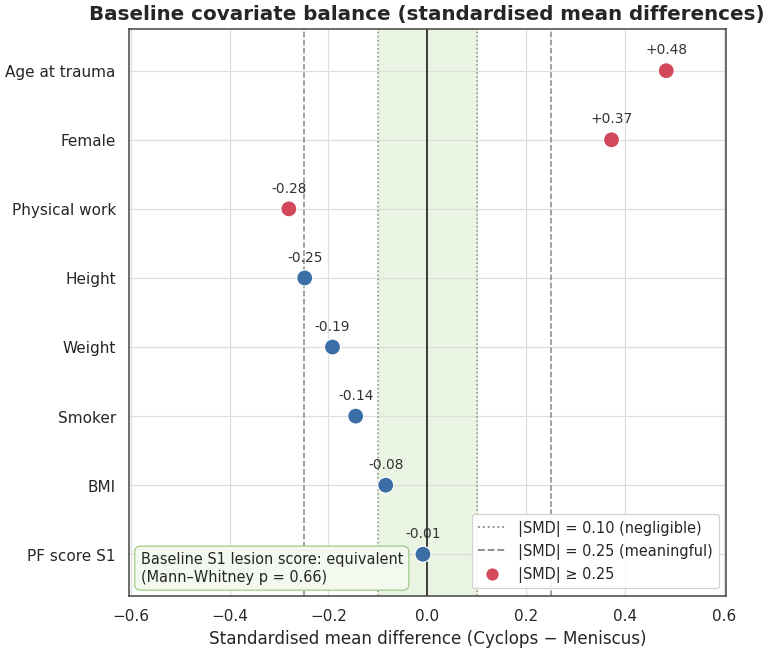

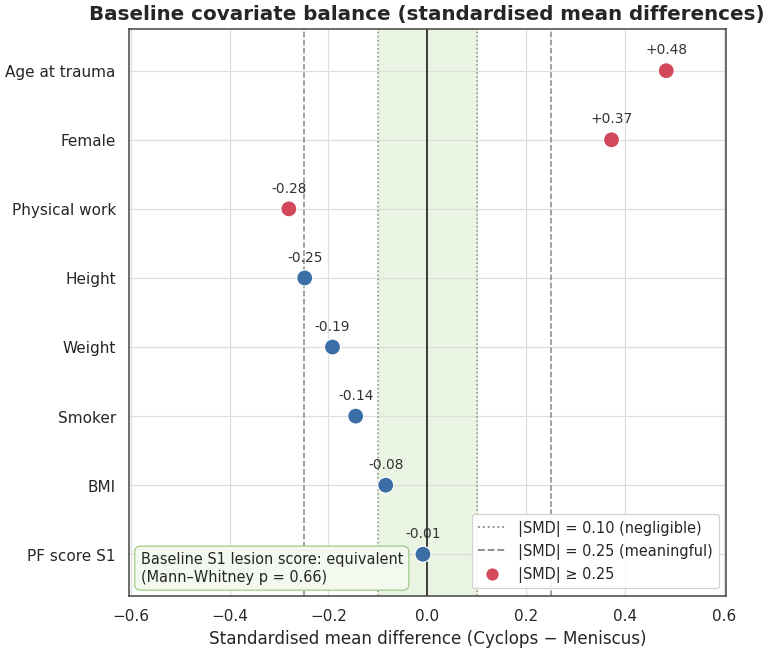

In [18]:
fig = viz.love_plot_smd(smd_rows, baseline_score_p=base["pvalue"])
fig  # display inline


## 2b. Baseline equivalence on the PF block at S1 (MWU + SMD + TOST)

The headline baseline check, on the **patellofemoral score at S1** that carries the primary outcome. `tf.baseline_pf_balance` reports the MWU p (difference test), the SMD, **and** a **TOST** equivalence p within a small-SMD margin (±0.5 pooled SD). `equivalent=True` ⇒ the PF starting point is *statistically equivalent*, so the PF progression contrast is not a regression-to-baseline artefact — and this is asserted positively, not inferred from a non-significant difference.

In [19]:
pf_bal = tf.baseline_pf_balance(wide, col="lesion_pf_S1")
print("Baseline PF block at S1 (cyclops vs meniscus):")
print(f"  n            : {pf_bal['n_case']} cyclops / {pf_bal['n_control']} meniscus")
print(f"  medians      : {pf_bal['median_case']:.1f} / {pf_bal['median_control']:.1f}")
print(f"  MWU p (diff) : {pf_bal['mwu_p']:.3f}")
print(f"  SMD          : {pf_bal['smd']:+.3f}")
print(f"  TOST bound   : +/- {pf_bal['tost_bound']:.3f} (pooled-SD margin)")
print(f"  TOST p (equiv): {pf_bal['tost_p']:.3f}")
print(
    f"  => equivalent: {pf_bal['equivalent']}  (TOST p < 0.05 establishes equivalence)"
)


Baseline PF block at S1 (cyclops vs meniscus):
  n            : 49 cyclops / 20 meniscus
  medians      : 0.0 / 0.0
  MWU p (diff) : 0.818
  SMD          : -0.009
  TOST bound   : +/- 0.292 (pooled-SD margin)
  TOST p (equiv): 0.034
  => equivalent: True  (TOST p < 0.05 establishes equivalence)


## 3. Per-test baseline detail (continuous MWU; categorical Fisher)

In [20]:
print("Continuous (Mann-Whitney U + Cliff delta):")
for var in ["age_at_trauma", "imc", "taille", "poids"]:
    if var not in patient.columns:
        continue
    c = pd.to_numeric(
        patient.loc[patient.group == "cyclops", var], errors="coerce"
    ).dropna()
    m = pd.to_numeric(
        patient.loc[patient.group == "meniscus", var], errors="coerce"
    ).dropna()
    r = tf.mwu_with_effects(c.values, m.values, n_boot=2000)
    print(f"  {var:16s} delta={r['cliffs_delta']:+.2f}  p={r['pvalue']:.3f}")

print("\nCategorical (Fisher exact 2x2):")
for var in ["female", "tabac", "travail_physique"]:
    if var not in patient.columns:
        continue
    tab = pd.crosstab(patient["group"], patient[var]).values
    if tab.shape != (2, 2):
        print(f"  {var}: not 2x2 ({tab.shape}) - skipped")
        continue
    r = tf.fisher_exact_2x2(tab)
    print(f"  {var:16s} OR={r['odds_ratio']:.2f}  p={r['pvalue']:.3f}")


Continuous (Mann-Whitney U + Cliff delta):
  age_at_trauma    delta=+0.27  p=0.084
  imc              delta=-0.08  p=0.615
  taille           delta=-0.17  p=0.272
  poids            delta=-0.15  p=0.340

Categorical (Fisher exact 2x2):
  female           OR=0.48  p=0.188
  tabac            OR=1.55  p=0.682
  travail_physique OR=1.86  p=0.366


## 4. Baseline S1 lesion scores per compartment (pre-progression)

In [21]:
s1 = df[df["surgery_num"] == 1]
for site in SITES + ["lesion_pf", "lesion_ft", "lesion_total"]:
    if site not in s1.columns:
        continue
    c = s1.loc[s1["group"] == "cyclops", site].dropna().astype(float).values
    m = s1.loc[s1["group"] == "meniscus", site].dropna().astype(float).values
    if len(c) < 2 or len(m) < 2:
        continue
    r = tf.mwu_with_effects(c, m, n_boot=500)
    print(
        f"{site:14s}  delta={r['cliffs_delta']:+.2f}  "
        f"CI=[{r['delta_ci_lo']:+.2f}, {r['delta_ci_hi']:+.2f}]  p={r['pvalue']:.3f}"
    )


trochlée        delta=+0.01  CI=[-0.13, +0.12]  p=0.870
rotule          delta=+0.01  CI=[-0.18, +0.22]  p=0.942
pte             delta=+0.07  CI=[-0.06, +0.20]  p=0.370
pti             delta=+0.02  CI=[-0.16, +0.16]  p=0.802
cfe             delta=+0.04  CI=[+0.00, +0.10]  p=0.375
cfi             delta=+0.05  CI=[-0.09, +0.18]  p=0.498
lesion_pf       delta=+0.02  CI=[-0.16, +0.23]  p=0.818
lesion_ft       delta=+0.03  CI=[-0.19, +0.22]  p=0.770
lesion_total    delta=+0.05  CI=[-0.16, +0.29]  p=0.662


## Sanity asserts

In [22]:
assert len(patient) == N_TOTAL
print("Baseline-balance asserts passed.")


Baseline-balance asserts passed.
